In [1]:
from obspy import UTCDateTime
import obspy
from obspy.clients.fdsn import Client
import random
from obspy.clients.fdsn import RoutingClient
from obspy import Stream
from obspy.geodetics import gps2dist_azimuth
from obspy import signal
from obspy import read
import csv
import matplotlib.pyplot as plt
import folium
import numpy as np
import json
import pandas as pd
from obspy.clients.fdsn.header import FDSNNoDataException
from scipy.signal import savgol_filter
import os
import folium
import numpy as np
import branca.colormap as cm
from scipy.signal import resample
from obspy import Stream
from matplotlib.colors import LogNorm

from shapely.geometry import box, LineString
from collections import defaultdict
from tqdm import tqdm






import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection






from plotting_routines import *
from processing_routines import *
Dtmin_Noise=-25
Dtmax_Noise=-5
Dtmin_Pn=-5.
Dtmax_Pn=10.
Dtmin_Sn=-5.
Dtmax_Sn=10.

vLg_max=3.5
vLg_min=3.1
vLg=0.5*(vLg_max+vLg_min)
vPg_max=6.2
vPg_min=5.2
vPg=0.5*(vPg_max+vPg_min)
print(vPg)
#vPg=6.

tminCoda=300.
tmaxCoda=320.
import warnings
warnings.filterwarnings("ignore")

5.7


In [2]:
from obspy.taup import TauPyModel

model = TauPyModel(model='ak135') #crust at 35 (?) , but only 3s difference with 11km crust 
t_Pn=111.*1/8.  #default value

arrivals = model.get_travel_times(source_depth_in_km=0,
                                distance_in_degree=1,phase_list=["Pn"])


try:
    t_Pn=arrivals [0].time +25
    print('Pn ', t_Pn)
    print('velocity Pn ',111/(t_Pn-25))
except Exception as e:
    print('no Pn ', 1, e)

Pn  46.273001774095945
velocity Pn  5.217881386874338


In [3]:
fmin = 2
fmax = 3
frequenciesmin = [0.5,2,4,6]
frequenciesmax = [1.5,3,6,8]
event_file='/home/schreinl/Stage/Data/big_box_4.5.csv'
best_bet = ['MLS','GRA1','SSB','BFO','LOR','SENIN','HASLI','BOURR','BNALP','DAVOX','FUORN','MOA','CONA','CLUD','OBKA','MONC','CIMO','ECH']

#calculate the site terms 
dict_test = create_coda_amplitude_dict(event_file='/home/schreinl/Stage/Data/big_box_4.5.csv', codawindow="cutoff", factor=1.1, fmin=fmin, fmax=fmax, data_dir='Data1',envelope_name='new')
ref_value_test = reference_stations_median(best_bet,event_file, fmin, fmax, envelope_name='new')
sites_effect_dict_test = site_effect_dict(event_file, fmin,fmax,best_bet,envelope_name='new')

site_effects = site_effect_overall(fmin,fmax,best_bet,frequenciesmin=frequenciesmin, frequenciesmax=frequenciesmax,method='multiple',map_plot=False,envelope_name='new')
filtered_site_effects = {}
for freq_band, stations in site_effects.items():
    filtered_site_effects[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 5
    }

all_site_terms = {}
for freq_band, stations in site_effects.items():
    all_site_terms[freq_band] = {
        station: data for station, data in stations.items() if data.get("num_points_after", 0) >= 0
    }

carte = map_site_effect(fmin, fmax, filtered_site_effects, method='multiple')
#carte.save(f"site_effect_{(fmin+fmax)/2}_Hz_map.html")
carte

done reading in


## Start tomography with Seislib

First the input data has to be brought into the correct shape. 

We can write the path specific inverse of the attenuation Q as $$  \alpha_{k,l} = - \frac{V}{\pi f R_{k,l}} ln \Bigl ( \frac{A_{k,l}}{S_k P_l} R_{k,l}^{5/6} \Bigr )$$, which is the same as the formulation of Q:



$$ Q_{k,l} = \frac{-\pi r f }{V} \left( ln(\frac{A_{k,l}}{G(r)}) - ln(P_l(f)) - ln(S_k(f))\right) ^{-1}. $$

Calculating now all path specific Q values, we can quickly find the correct shape of data input for the inversion.
Now we have to put our input data into the right shape. Seislib demands a matrix of shape (n,5), n being the amount of path specific measurements, while the columns are lat1, lon1, lat2, lon2 and velocity. As mentioned above,




Processing complete.
209 events in total
21 events dropped due to insufficient std on Q0
0 events dropped due to insufficient data points
Processed 188 events with Q0 and Sk values.
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -4.153 - 19.948
Latmin - Latmax data : 40.078 - 51.997
Number of measurements : 40927
Source : Unknown
-------------------------------------

40.0783 51.99733 -4.152724 19.9477
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 24

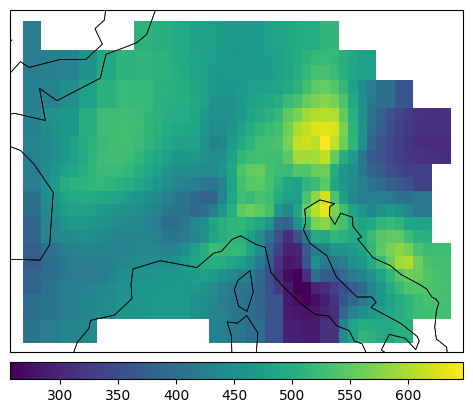

In [12]:
# finding all path specific Q values:
from seislib.tomography import SeismicTomography
from scipy.stats import zscore
fmin = 2
fmax = 3
Qkl = Lg_Q_kl(fmin, fmax,special_site_terms=filtered_site_effects)
matrix = []

for event_id, event_data in Qkl.items():
    event_coords = event_data['coordinates'] 
    stations = event_data['stations']  

    for station, station_data in stations.items():
        station_coords = station_data.get('coordinates', {})
        qkl_value = station_data.get('Qkl', None)

        if event_coords and station_coords and qkl_value is not None:
            row = [
                event_coords.get('latitude'),  
                event_coords.get('longitude'),  
                station_coords.get('latitude'),  
                station_coords.get('longitude'), 
                qkl_value  
            ]
            matrix.append(row)


matrix = np.array(matrix)

#matrix[:, -1] = np.clip(matrix[:, -1], 180, 450)


#z_scores = zscore(matrix[:, -1])
#z_threshold = 1
#matrix = matrix[np.abs(z_scores) <= z_threshold]


matrix = matrix[(matrix[:, -1] > 150) & (matrix[:, -1] <= 700)]
matrix = matrix[~np.isinf(matrix).any(axis=1)]
matrix = matrix[~np.isnan(matrix).any(axis=1)]








#do the tomography with Seislib


#tomo = SeismicTomography(cell_size=1, regular_grid=False, verbose=True)
tomo = SeismicTomography(cell_size=1, 
                         regular_grid=True, 
                        latmin=40.078,
                             latmax=51.966,
                             lonmin=-2.827 ,
                             lonmax=19.948,
                         verbose=True)

tomo.add_data(data=matrix)
print(tomo.latmin_data,tomo.latmax_data,tomo.lonmin_data,tomo.lonmax_data)

tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    

slowness = 1 / matrix[:, -1]


Q = 1/tomo.solve(rdamp=0.05)
print(tomo.refvel)
print(max(Q))
print(min(Q))
print(np.mean(Q))
print(np.std(Q))
tomo.plot_map(tomo.grid.mesh, Q)

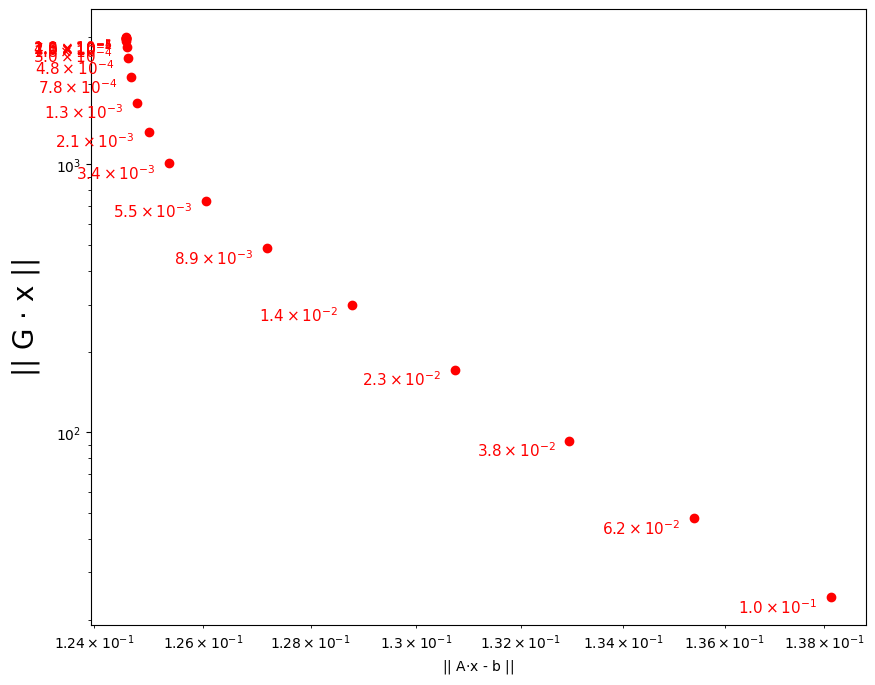

In [5]:
l = tomo.lcurve()

In [ ]:
def tomo_Q(fmin,fmax):
    '''
    Function to do all the processing, as well as plotting of Lg Q

    Input:
        - fmin: float, minimum frequency
        - fmax: float, maximum frequency


    '''

    

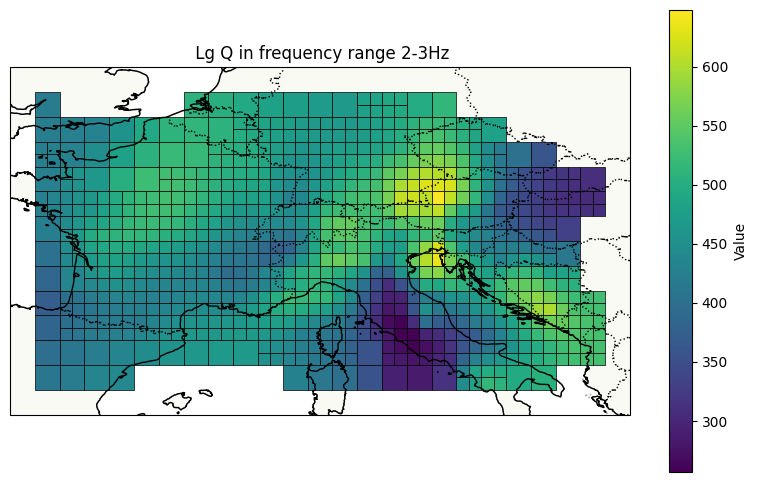

In [7]:
def plot_seislib_grid(meshndarray, c):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    min_lon = np.min(np.minimum(meshndarray[:, 2], meshndarray[:, 3]))
    max_lon = np.max(np.maximum(meshndarray[:, 2], meshndarray[:, 3]))
    min_lat = np.min(np.minimum(meshndarray[:, 0], meshndarray[:, 1]))
    max_lat = np.max(np.maximum(meshndarray[:, 0], meshndarray[:, 1]))

    padding = 1.0
    ax.set_extent([min_lon - padding, max_lon + padding, 
                   min_lat - padding, max_lat + padding], crs=ccrs.PlateCarree())

    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', alpha=0.3)

    patches = []
    colors = []

    for i in range(meshndarray.shape[0]):
        lat1, lat2, lon1, lon2 = meshndarray[i]
        lon = min(lon1, lon2)
        lat = min(lat1, lat2)
        width = abs(lon2 - lon1)
        height = abs(lat2 - lat1)
        rect = Rectangle((lon, lat), width, height)
        patches.append(rect)
        colors.append(c[i])

    p = PatchCollection(patches, cmap='viridis', edgecolor='k', linewidth=0.5)
    p.set_array(np.array(colors))
    ax.add_collection(p)

    from matplotlib.ticker import FuncFormatter

    def fixed_formatter(x, pos):
        return f"{x:.0f}"  # Use .1f or .2f if you want decimals

    cb = plt.colorbar(p, ax=ax, orientation='vertical', label='Value')
    cb.ax.yaxis.set_major_formatter(FuncFormatter(fixed_formatter))    
    ax.set_title(f" Lg Q in frequency range {fmin}-{fmax}Hz")
    plt.show()


plot_seislib_grid(tomo.grid.mesh, Q)

Damping value: 0.0001


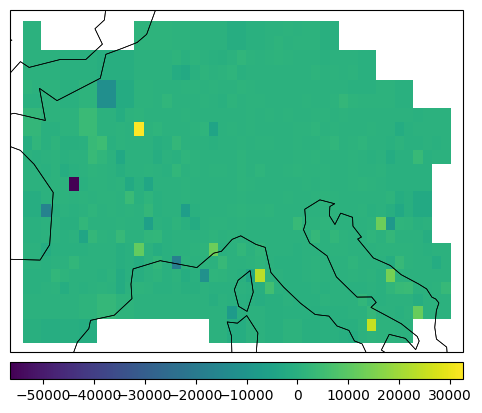

Damping value: 0.0007943282347242813


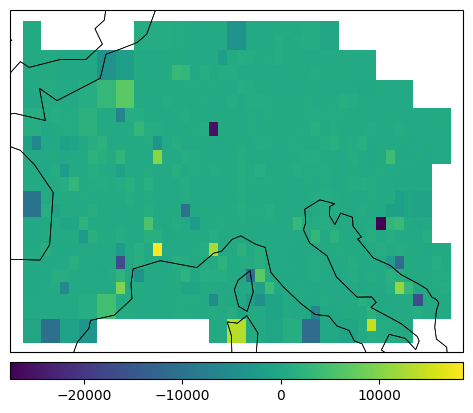

Damping value: 0.00630957344480193


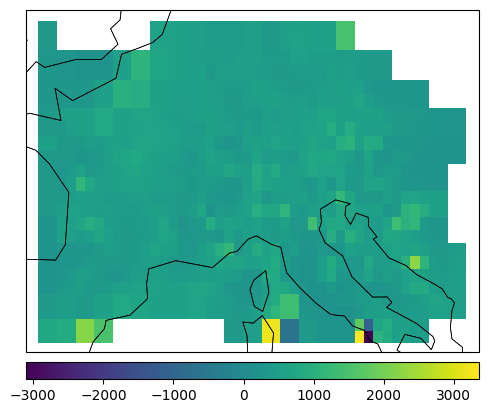

Damping value: 0.05011872336272725


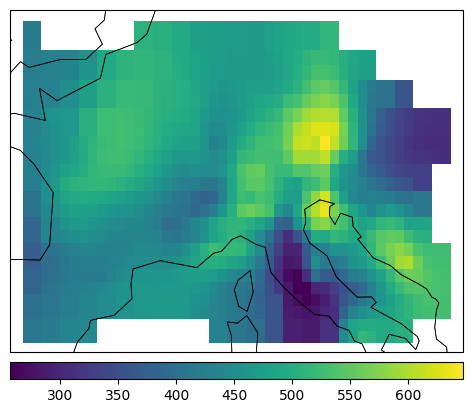

Damping value: 0.3981071705534973


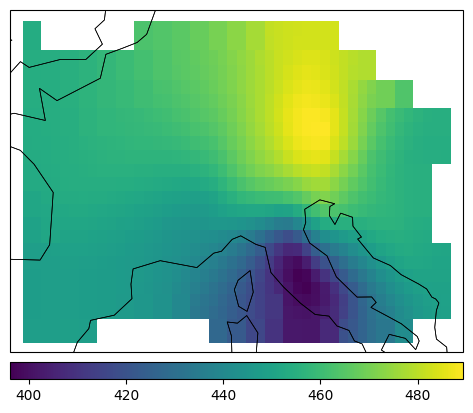

Damping value: 3.1622776601683795


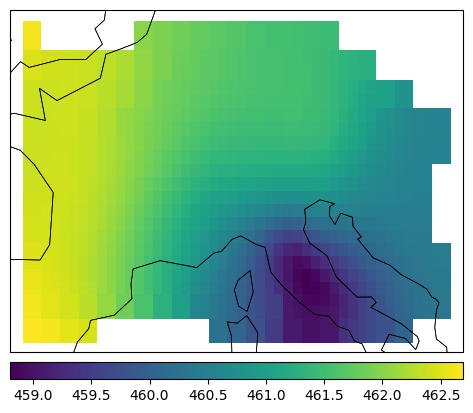

Damping value: 25.11886431509582


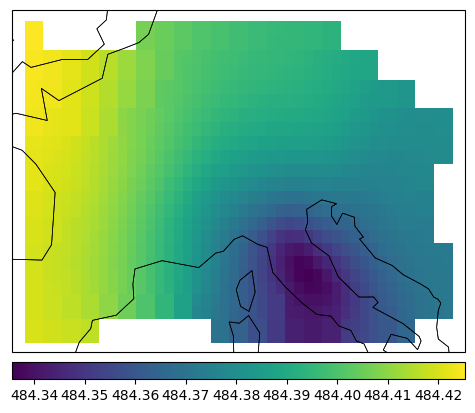

Damping value: 199.52623149688787


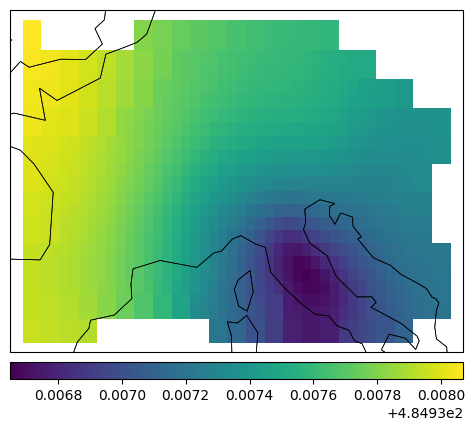

Damping value: 1584.893192461114


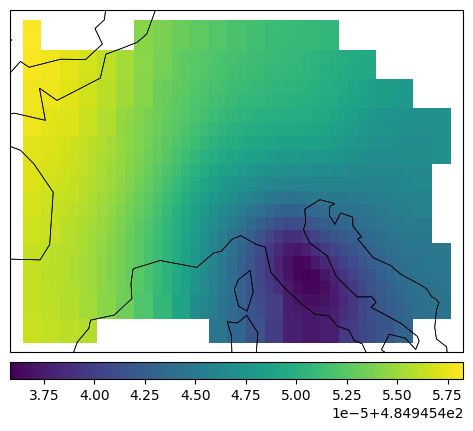

Damping value: 12589.254117941662


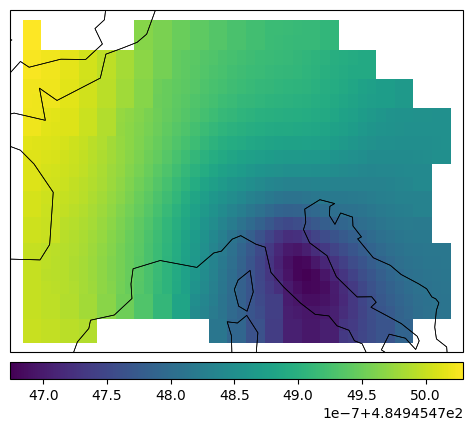

Damping value: 100000.0


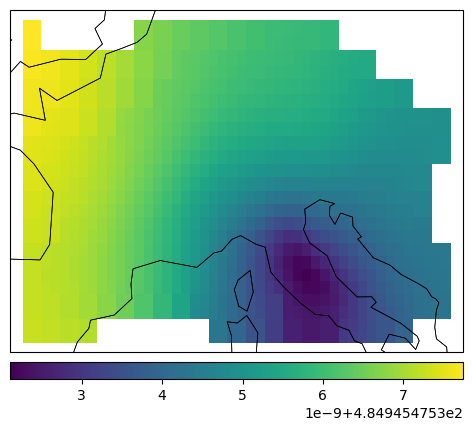

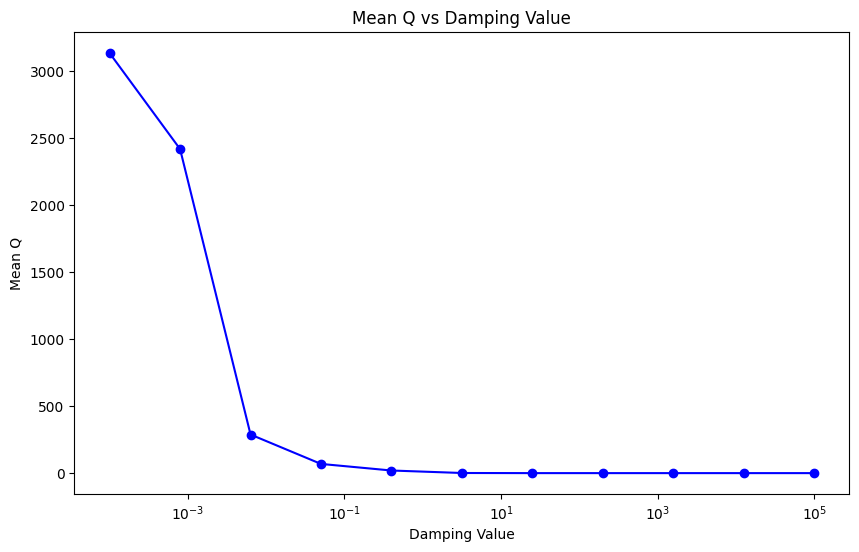

In [ ]:
rdamping_values = np.logspace(-4, 5, num=int(5 / 0.5) + 1)
Q_different_damping = np.zeros((len(rdamping_values), 5))  # Adjusted array size to match ndamping_values
for i, damping in enumerate(rdamping_values):
    print(f"Damping value: {damping}")
    Q = 1/tomo.solve(rdamp=damping, ndamp=1e-2)
    Q_different_damping[i, 0] = damping
    Q_different_damping[i, 1] = np.mean(Q)
    Q_different_damping[i, 2] = np.std(Q)
    Q_different_damping[i, 3] = np.max(Q)
    Q_different_damping[i, 4] = np.min(Q)
    tomo.plot_map(tomo.grid.mesh, Q)

plt.figure(figsize=(10, 6))
plt.semilogx(rdamping_values, Q_different_damping[:, 2], label='Std Q', color='blue', marker='o')
#plt.ylim([0,500])
plt.title('Mean Q vs Damping Value')
plt.xlabel('Damping Value')
plt.ylabel('Mean Q')
#plt.plot(damping_values, Q_different_damping[:, 2], label='Std Q')
#
plt.show()

In [8]:
noise = np.random.uniform(0, 50, size=matrix.shape[0])
matrix[:, -1] =  500 + noise
print("Updated matrix with noise added to the last column.")

Updated matrix with noise added to the last column.


In [9]:
matrix = matrix[~np.isinf(matrix).any(axis=1)]
print("New shape after removing rows with inf values:", matrix.shape)
print(np.mean(matrix[:, -1]))

New shape after removing rows with inf values: (40927, 5)
525.0268114688876


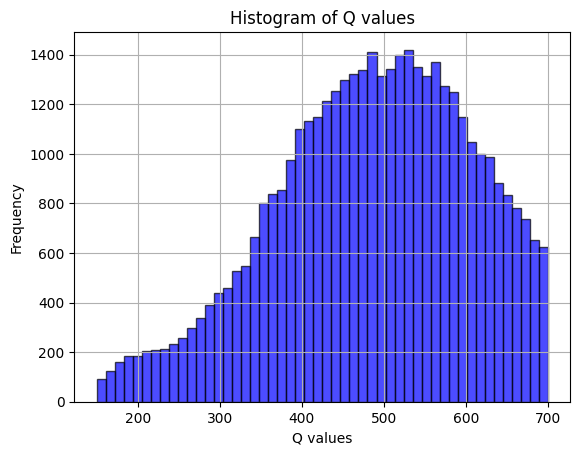

Mean Q value 484.94547529190277
Median Q value 493.34805711328727
Standard deviation Q value 119.74950916439346


In [13]:
plt.hist(matrix[:, -1], bins=50, color='blue', alpha=0.7, edgecolor='black')#,range=(-111, 1400))
plt.xlabel('Q values')
plt.ylabel('Frequency')
plt.title('Histogram of Q values')
plt.grid(True)
plt.show()


print('Mean Q value',np.mean(matrix[:, -1]))
print('Median Q value',np.median(matrix[:, -1]))
print('Standard deviation Q value',np.std(matrix[:, -1]))

In [14]:
valid_count = 0
for event_data in Qkl.values():
    if not isinstance(event_data, dict): continue
    for sdata in event_data.get("stations", {}).values():
        if sdata.get("observable") is not None:
            valid_count += 1

print("Valid station-observations:", valid_count)


Valid station-observations: 57293


 updated matrix with noise added to the last column.
-------------------------------------
Optimal grid found in 91 iterations
-------------------------------------
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -180.000 - 180.000
Latmin - Latmax : -90.000 - 90.000
Number of cells : 41252
Grid cells of 1.000° : 41252
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -4.153 - 19.948
Latmin - Latmax data : 40.078 - 51.997
Number of measurements : 40927
Source : Unknown
-------------------------------------

*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -5.502 - 21.223
Latmin - Latmax : 39.999 - 52.002
Number of cells : 211
Grid cells of 1.000° : 211
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -5.502 - 21.057
Latmin - Latmax : 39.999 - 52.002
Number of cells : 191
Grid cells of 1.000° : 191
---------------

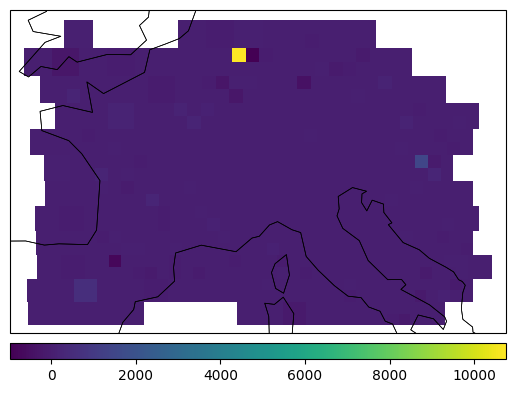

In [11]:
from seislib.tomography import SeismicTomography

ref = 3

noise = np.random.uniform(0, 30, size=matrix.shape[0])
matrix[:, -1] =  ref + noise
print(" updated matrix with noise added to the last column.")



tomo = SeismicTomography(cell_size=1, regular_grid=False, verbose=True)


tomo.add_data(data=matrix)
tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    

slowness = 1 / matrix[:, -1]

Q = 1 / tomo.solve(refvel=ref)
print("Q shape:", Q.shape)
print("Mesh shape:", tomo.grid.mesh.shape)
tomo.plot_map(tomo.grid.mesh, Q)

In [132]:
print(tomo.grid)


-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -3.766 - 21.057
Latmin - Latmax : 39.999 - 52.002
Number of cells : 579
Grid cells of 1.000° : 43
Grid cells of 0.500° : 536
-------------------------------------


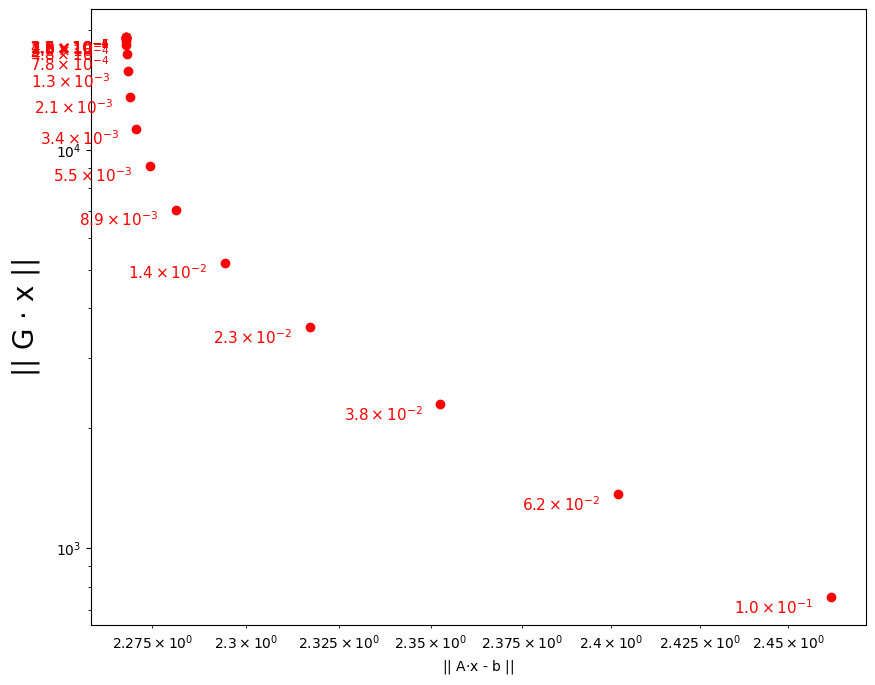

(array([1.00000000e-05, 1.62377674e-05, 2.63665090e-05, 4.28133240e-05,
        6.95192796e-05, 1.12883789e-04, 1.83298071e-04, 2.97635144e-04,
        4.83293024e-04, 7.84759970e-04, 1.27427499e-03, 2.06913808e-03,
        3.35981829e-03, 5.45559478e-03, 8.85866790e-03, 1.43844989e-02,
        2.33572147e-02, 3.79269019e-02, 6.15848211e-02, 1.00000000e-01]),
 [(2.268063617305648, 19152.858822722686),
  (2.2680649118956935, 19144.705482737714),
  (2.268064532360558, 19145.737645419395),
  (2.268066456379862, 19130.84039762481),
  (2.268074261981202, 19077.02060289148),
  (2.268065429312489, 19105.606384297975),
  (2.2680737306503786, 18999.833143045857),
  (2.2680839641604105, 18800.309907600797),
  (2.2681059223728353, 18359.545328000513),
  (2.268182068329814, 17400.03919125026),
  (2.268435216753616, 15733.477310217235),
  (2.269113275420211, 13566.47622359056),
  (2.270749600693394, 11294.126921120418),
  (2.274242897258077, 9115.52901638309),
  (2.281172464005624, 7077.23348016635

In [192]:
tomo.lcurve()

In [20]:
Q = 1/tomo.solve(rdamp=0.05)

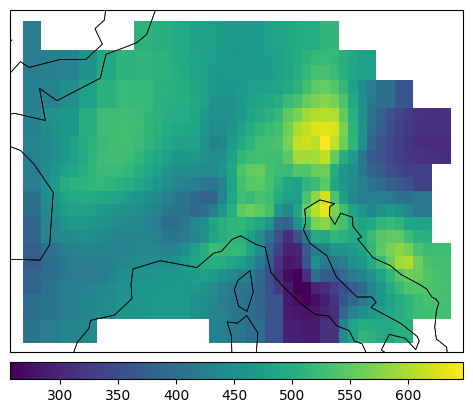

In [21]:
tomo.plot_map(tomo.grid.mesh, Q)

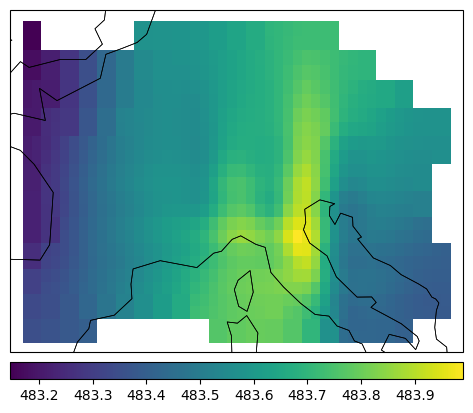

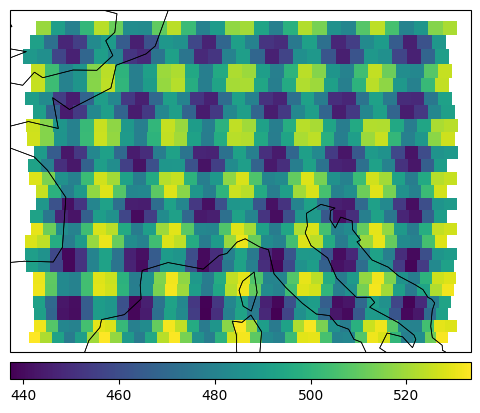

In [24]:
restest = tomo.checkerboard_test(kx=6,
                                 ky=6,
                                 latmin=tomo.grid.latmin,
                                 latmax=tomo.grid.latmax,
                                 lonmin=tomo.grid.lonmin,
                                 lonmax=tomo.grid.lonmax,
                                 cell_size=0.5,
                                 anom_amp=0.1,
                                 noise=0,
                                 rdamp=1)

input_model = 1 / restest['synth_model']
input_mesh = restest['mesh']
retrieved_model = 1 / restest['retrieved_model']

tomo.plot_map(tomo.grid.mesh, retrieved_model)
tomo.plot_map(input_mesh, input_model)


Text(0.5, 1.0, 'Raypaths per pixel')

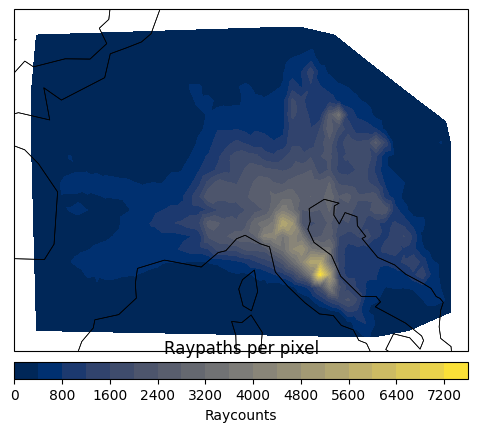

In [25]:
raypaths = tomo.raypaths_per_pixel()
img, cb = tomo.plot_map(mesh=tomo.grid.mesh, 
                        c=raypaths, 
                        cmap='cividis', 
                        style='contourf', 
                        levels=20,
                        show=False)
cb.set_label('Raycounts')
plt.title('Raypaths per pixel')

In [ ]:
from branca.colormap import LinearColormap

def plot_Qkl_map(Qkl_dict, fmin, fmax):
    Qkl_values = []
    for event in Qkl_dict.values():
        if 'stations' in event: 
            for station, station_data in event['stations'].items():
                Qkl = station_data.get('Qkl', None)
                if Qkl is not None and np.isfinite(Qkl):  # Filter out None and NaN values
                    Qkl_values.append(Qkl)

    if not Qkl_values:
        raise ValueError("No valid Qkl values found for plotting.")

    Qkl_values.sort()

    vmin = np.percentile(Qkl_values, 5)
    vmax = np.percentile(Qkl_values, 95)
    if vmin > vmax:
        vmin, vmax = sorted([vmin, vmax])

    colormap = LinearColormap(
        colors=["blue", "green", "yellow", "orange", "red"],
        vmin=vmin,
        vmax=vmax
    )

    latitudes = []
    longitudes = []

    for event in Qkl_dict.values():
        if 'coordinates' in event:
            event_lat = event['coordinates'].get('latitude')
            event_lon = event['coordinates'].get('longitude')
            if event_lat is not None and event_lon is not None:
                latitudes.append(event_lat)
                longitudes.append(event_lon)

        for station, station_data in event.get('stations', {}).items():
            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')
            if station_lat is not None and station_lon is not None:
                latitudes.append(station_lat)
                longitudes.append(station_lon)

    event_map = folium.Map(
        location=[np.mean(latitudes), np.mean(longitudes)],
        zoom_start=5,
        tiles="OpenStreetMap",
    )

    for event_time, event in Qkl_dict.items():
        if 'coordinates' not in event:
            continue
        event_lat = event['coordinates'].get('latitude')
        event_lon = event['coordinates'].get('longitude')

        if event_lat is None or event_lon is None:
            continue

        for station, station_data in event.get('stations', {}).items():
            Qkl = station_data.get('Qkl', None)
            if Qkl is None or not np.isfinite(Qkl):  # Skip invalid Qkl values
                continue

            station_lat = station_data['coordinates'].get('latitude')
            station_lon = station_data['coordinates'].get('longitude')

            folium.PolyLine(
                locations=[(event_lat, event_lon), (station_lat, station_lon)],
                color=colormap(Qkl), 
                weight=2,
                opacity=0.2,  # Set transparency
                tooltip=f"Event: {event_time}<br>Station: {station}<br>Qkl: {Qkl:.2f}"
            ).add_to(event_map)

    colormap.add_to(event_map)

    return event_map

Qkl_map = plot_Qkl_map(Qkl, fmin=0.5, fmax=1.5)
Qkl_map

#### Inversion testing

In order to find and understand the behaviour of the inversion, we will create a known model, and will try to retrieve it with the inversion. To do so, we can use all the real event-station couples, and calculate the path specific Qkl for each couple. Qkl will be computed by gridding the input model, fundamentally solving a forward problem. This Qkl is defined over a sum, of the multiplication of the length of a ray within a cell, and the cellvalue, normalised by the length of the ray. Doing this we can refind

[[False False False ...  True  True  True]
 [False False False ...  True  True  True]
 [False False False ...  True  True  True]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


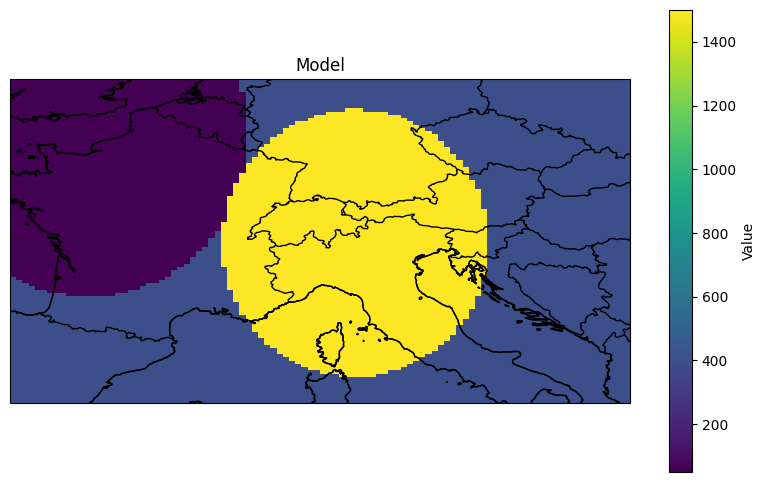

In [58]:
def model_building(basevalue=400,bloblist=[100,1000], blobsizes=[4,3] ,blobmiddles= [(50,0),(46,10)],latmin=40.078, latmax=52.078, lonmin=-2.827, lonmax=20.173):
    #creating a grid, with the basevalue for each gridcell value. Then, if there is a bloblist, the amount of bloblist values is the
    # number of blobs, and the value is the value of the blob.
    lat = np.linspace(latmin,latmax,100)
    lon = np.linspace(lonmin,lonmax,100)
    lat, lon = np.meshgrid(lat, lon)
    grid = np.zeros((lat.shape[0],lat.shape[1]))
    grid.fill(basevalue)
    for i in range(len(bloblist)):
        lat_blob = blobmiddles[i][0]
        lon_blob = blobmiddles[i][1]
        size_blob = blobsizes[i]
        value_blob = bloblist[i]
        grid[(lat-lat_blob)**2 + (lon-lon_blob)**2 < size_blob**2] = value_blob
        print((lat-lat_blob)**2 + (lon-lon_blob)**2 < size_blob**2)
    return grid,lat,lon

model,lat,lon = model_building(bloblist=[50,1500],blobsizes=[6,5])









def plot_model(lat, lon, grid):
    fig = plt.figure(figsize=(10, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    c = ax.pcolormesh(lon, lat, grid, shading='auto', cmap='viridis', transform=ccrs.PlateCarree())
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    ax.add_feature(cfeature.COASTLINE, edgecolor='black')

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Model')
    fig.colorbar(c, ax=ax, orientation='vertical', label='Value')

    plt.show()


plot_model(lat,lon,model)

In [69]:
from skimage.draw import line
from geopy.distance import geodesic

def model_building(basevalue=400,bloblist=[100,1000], blobsizes=[4,3] ,blobmiddles= [(50,0),(46,10)],latmin=40.078, latmax=52.078, lonmin=-2.827, lonmax=20.173):
    #creating a grid, with the basevalue for each gridcell value. Then, if there is a bloblist, the amount of bloblist values is the
    # number of blobs, and the value is the value of the blob.
    lat = np.linspace(latmin,latmax,1000)
    lon = np.linspace(lonmin,lonmax,1000)
    lat, lon = np.meshgrid(lat, lon)
    grid = np.zeros((lat.shape[0],lat.shape[1]))
    grid.fill(basevalue)
    for i in range(len(bloblist)):
        lat_blob = blobmiddles[i][0]
        lon_blob = blobmiddles[i][1]
        size_blob = blobsizes[i]
        value_blob = bloblist[i]
        grid[(lat-lat_blob)**2 + (lon-lon_blob)**2 < size_blob**2] = value_blob
    return grid,lat,lon


def forward_modelling(couples, model, lat_grid, lon_grid):
    """
    Parameters:
        couples: list of n x 2 tuples, each with ((lat_event, lon_event), (lat_station, lon_station))
        model: 2D numpy array with Q values
        lat_grid: 2D grid of latitudes (same shape as model)
        lon_grid: 2D grid of longitudes (same shape as model)

    Should calculate the value of Q along the path between the event and the station.

    Returns:
        results: n x 5 numpy array: lat_event, lon_event, lat_station, lon_station, average_Q
    """
    results = []

    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station

        y1 = np.argmin(np.abs(lat_grid[:, 0] - lat1))
        x1 = np.argmin(np.abs(lon_grid[0, :] - lon1))
        y2 = np.argmin(np.abs(lat_grid[:, 0] - lat2))
        x2 = np.argmin(np.abs(lon_grid[0, :] - lon2))

        rr, cc = line(y1, x1, y2, x2)

        q_vals = []
        dists = []

        print(len(rr))
        for i in range(len(rr)-1):
            q = model[rr[i], cc[i]]
            print(f"Index: ({rr[i]}, {cc[i]}) -> Q: {q}")
        #for i in range(len(rr) - 1):
        #    q = model[rr[i], cc[i]]

            lat_a = lat_grid[rr[i], cc[i]]
            lon_a = lon_grid[rr[i], cc[i]]
            lat_b = lat_grid[rr[i + 1], cc[i + 1]]
            lon_b = lon_grid[rr[i + 1], cc[i + 1]]

            dist = geodesic((lat_a, lon_a), (lat_b, lon_b)).km

            q_vals.append(q)
            dists.append(dist)

        total_dist = np.sum(dists)

        if y1 == y2 and x1 == x2:  
            results.append([lat1, lon1, lat2, lon2, model[y1, x1]])
            continue
        else:
            avg_q = np.sum(np.array(q_vals) * np.array(dists)) / total_dist

        results.append([lat1, lon1, lat2, lon2, avg_q])

    return np.array(results)



model,lat,lon = model_building(bloblist=[50,1500],blobsizes=[6,5])

#plot_model(lat,lon,model)
couples = matrix[:, :-1]
couples_tuples = [((row[0], row[1]), (row[2], row[3])) for row in couples]
#print(couples_tuples)
#esults = forward_modelling(couples_tuples, model, lat, lon)


In [ ]:
import numpy as np
from geopy.distance import geodesic
from geopy import Point
from geopy.distance import distance as geopy_distance

def interpolate_geodesic_path(lat1, lon1, lat2, lon2, step_km=1):
    """Generate lat/lon points every ~step_km along the geodesic path."""
    total_dist = geodesic((lat1, lon1), (lat2, lon2)).km
    n_steps = int(total_dist // step_km)
    points = []
    for f in np.linspace(0, 1, n_steps + 1):
        lat = lat1 + f * (lat2 - lat1)
        lon = lon1 + f * (lon2 - lon1)
        points.append((lat, lon))
    return points

def forward_modelling_improved(couples, model, lat_grid, lon_grid, step_km=1):
    results = []
    nrows, ncols = model.shape

    lat_vals = lat_grid[:, 0]
    lon_vals = lon_grid[0, :]

    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station

        path_points = interpolate_geodesic_path(lat1, lon1, lat2, lon2, step_km=step_km)

        q_vals = []
        dists = []

        for i in range(len(path_points) - 1):
            lat_a, lon_a = path_points[i]
            lat_b, lon_b = path_points[i + 1]

            # Find nearest indices
            y = np.argmin(np.abs(lat_vals - lat_a))
            x = np.argmin(np.abs(lon_vals - lon_a))
            if 0 <= y < nrows and 0 <= x < ncols:
                q = model[y, x]
                q_vals.append(q)
                dists.append(geodesic((lat_a, lon_a), (lat_b, lon_b)).km)

        total_dist = np.sum(dists)

        if total_dist == 0:
            y = np.argmin(np.abs(lat_vals - lat1))
            x = np.argmin(np.abs(lon_vals - lon1))
            results.append([lat1, lon1, lat2, lon2, model[y, x]])
        else:
            avg_q = np.sum(np.array(q_vals) * np.array(dists)) / total_dist
            results.append([lat1, lon1, lat2, lon2, avg_q])

    return np.array(results)


results = forward_modelling_improved(couples_tuples, model, lat, lon, step_km=1)

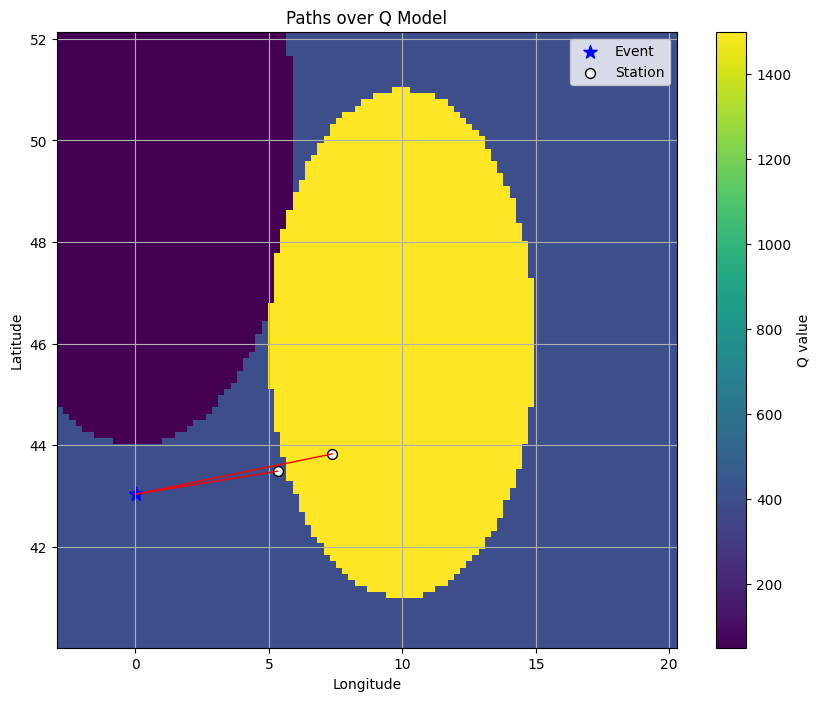

In [54]:

def plot_paths(model, lat_grid, lon_grid, couples):
    """
    Plot the Q model and the event-station paths.
    
    Parameters:
        model: 2D numpy array of Q values
        lat_grid: 2D array of latitudes
        lon_grid: 2D array of longitudes
        couples: list of ((lat_event, lon_event), (lat_station, lon_station)) pairs
    """
    plt.figure(figsize=(10, 8))
    
    plt.pcolormesh(lon_grid, lat_grid, model, shading='auto', cmap='viridis')
    plt.colorbar(label='Q value')
    
    for (event, station) in couples:
        lat1, lon1 = event
        lat2, lon2 = station
        plt.plot([lon1, lon2], [lat1, lat2], color='red', linewidth=1)
        
        plt.scatter(lon1, lat1, color='blue', marker='*', s=100, label='Event' if 'Event' not in plt.gca().get_legend_handles_labels()[1] else "")
        plt.scatter(lon2, lat2, color='white', edgecolor='black', marker='o', s=50, label='Station' if 'Station' not in plt.gca().get_legend_handles_labels()[1] else "")
    
    plt.xlabel('Longitude')
    
    plt.ylabel('Latitude')
    plt.title('Paths over Q Model')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_paths(model, lat, lon, couples_tuples)


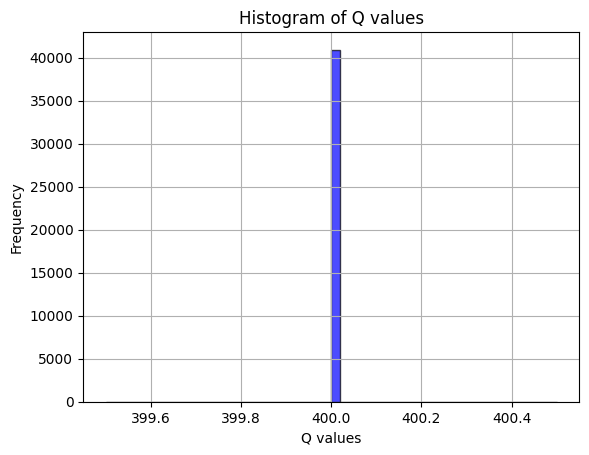

Mean Q value 400.0
Median Q value 400.0
Standard deviation Q value 0.0


In [46]:
plt.hist(results[:, -1], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.xlabel('Q values')
plt.ylabel('Frequency')
plt.title('Histogram of Q values')
plt.grid(True)
plt.show()


print('Mean Q value',np.mean(results[:, -1]))
print('Median Q value',np.median(results[:, -1]))
print('Standard deviation Q value',np.std(results[:, -1]))

-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
DATA PARAMETERS
Lonmin - Lonmax data : -4.153 - 19.948
Latmin - Latmax data : 40.078 - 51.997
Number of measurements : 40927
Source : Unknown
-------------------------------------

40.0783 51.99733 -4.152724 19.9477
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 276
Grid cells of 1.000° : 276
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin - Latmax : 40.078 - 52.078
Number of cells : 248
Grid cells of 1.000° : 248
-------------------------------------
*** GRID UPDATED ***
-------------------------------------
GRID PARAMETERS
Lonmin - Lonmax : -2.827 - 20.173
Latmin

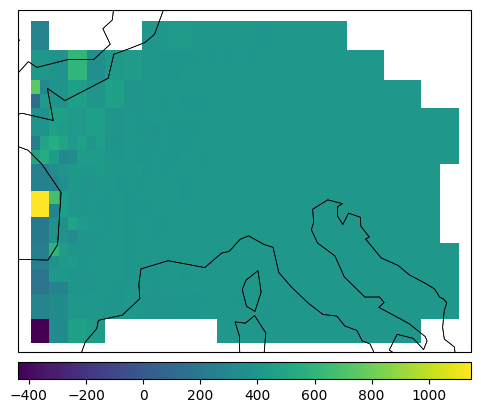

In [ ]:
tomo = SeismicTomography(cell_size=1, 
                         regular_grid=True, 
                        latmin=40.078,
                             latmax=51.966,
                             lonmin=-2.827 ,
                             lonmax=19.948,
                         verbose=True)

tomo.add_data(data=results)
print(tomo.latmin_data,tomo.latmax_data,tomo.lonmin_data,tomo.lonmax_data)

tomo.grid.set_boundaries(latmin=tomo.latmin_data,
                             latmax=tomo.latmax_data,
                             lonmin=tomo.lonmin_data,
                             lonmax=tomo.lonmax_data)


tomo.compile_coefficients(keep_empty_cells=False)

tomo.refine_parameterization(hitcounts=150,keep_empty_cells=True)    

tomo

Q = 1/tomo.solve()
print(tomo.refvel)
print(max(Q))
print(min(Q))
print(np.mean(Q))
print(np.std(Q))
tomo.plot_map(tomo.grid.mesh, Q)

In [73]:
from skimage.draw import line
from geopy.distance import geodesic

def forward_testing(couples, model, lat_axis, lon_axis):
    """
    Parameters:
        couples: list of n x 2 tuples, each with ((lat_event, lon_event), (lat_station, lon_station))
        model: 2D numpy array with Q values, shape (len(lat_axis), len(lon_axis))
        lat_axis: 1D array of latitude grid values (ascending)
        lon_axis: 1D array of longitude grid values (ascending)

    Returns:
        results: n x 5 numpy array: lat_event, lon_event, lat_station, lon_station, average_Q
    """

    results = []

    for row in couples:
        eventlat = float(row[0])
        eventlon = float(row[1])
        stationlat = float(row[2])
        stationlon = float(row[3])

        # Ensure the coordinates are within bounds
        if not (lat_axis[0] <= eventlat <= lat_axis[-1] and
        lon_axis[0] <= eventlon <= lon_axis[-1] and
            lat_axis[0] <= stationlat <= lat_axis[-1] and
            lon_axis[0] <= stationlon <= lon_axis[-1]):
            print(f"Skipping out-of-bounds coordinates: ({eventlat}, {eventlon}) to ({stationlat}, {stationlon})")
            continue

        y1 = np.argmin(np.abs(lat_axis - lat1))
        x1 = np.argmin(np.abs(lon_axis - lon1))
        y2 = np.argmin(np.abs(lat_axis - lat2))
        x2 = np.argmin(np.abs(lon_axis - lon2))

        rr, cc = line(y1, x1, y2, x2)

        q_vals = []
        dists = []

        for i in range(len(rr) - 1):
            q = model[rr[i], cc[i]]

            lat_a = lat_axiSs[rr[i]]
            lon_a = lon_axis[cc[i]]
            lat_b = lat_axis[rr[i + 1]]
            lon_b = lon_axis[cc[i + 1]]

            dist = geodesic((lat_a, lon_a), (lat_b, lon_b)).km
            q_vals.append(q)
            dists.append(dist)

        total_length = np.sum(dists)
        if total_length == 0:
            average_q = np.nan 
        else:
            weighted_q = np.sum(np.array(q_vals) * np.array(dists)) / total_length
            average_q = weighted_q

        results.append([lat1, lon1, lat2, lon2, average_q])

    return np.array(results)


couples = matrix[:, :4]
print(type(couples))
#testQkl = forward_testing(couples, model, lat, lon)

<class 'numpy.ndarray'>
